<h2 style="text-align: center;"> Proyecto Final Reciclaje </h2>

<img src="img/ITQ.jpg" width="700">

**Nombre:** *Sebastian Sampedro* <br>
**Fecha:** *9/7/2026* <br>
**Link Github:** "https://github.com/sdsampedro-byte/Python2026ML"


# SISTEMA INTELIGENTE PARA LA CLASIFICACIÓN DE RESIDUOS RECICLABLES MEDIANTE VISIÓN ARTIFICIAL  BAJO LA METODOLOGÍA CRISP-DM





# FASE 1 - COMPRENSIÓN DEL NEGOCIO (CRISP-DM)


## Problema

La clasificación manual presenta errores humanos.

## Pregunta de investigación

¿Es posible desarrollar un sistema inteligente basado en EfficientNetB0?


# FASE 2 - COMPRENSIÓN DE LOS DATOS (CRISP-DM)

In [ ]:
# ============================================================
# INSTALACION DE LIBRERIAS
# ============================================================
#   - tensorflow      -> crear y entrenar la red neuronal (Deep Learning)
#   - matplotlib      -> dibujar graficas (accuracy, loss, distribucion)
#   - seaborn         -> permite mejor diseño de graficas  (matriz de confusion)
#   - kaggle          -> descargar el dataset TrashNet desde Kaggle
#   - scikit-learn    -> metricas de evaluacion (reporte y matriz de confusion)
!pip install tensorflow matplotlib seaborn kaggle scikit-learn

In [1]:

# IMPORTACION DE LIBRERIAS

import os                         # manejar carpetas y rutas de archivos
import numpy as np                # operaciones con matrices/numeros (arrays)
import pandas as pd               # manejar tablas de datos (no muy usado aqui)
import matplotlib.pyplot as plt   # graficas basicas
import seaborn as sns             # graficas estadisticas (matriz de confusion)
import tensorflow as tf           # libreria principal de Deep Learning
import zipfile

C:\Users\ADMIN-ITQ\anaconda3\envs\clasificadorbasura\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Descargar Dataset

In [2]:
#Configuramos el entorno de descarga
import os
os.environ['KAGGLE_CONFIG_DIR']="C:/Users/ADMIN-ITQ/.kaggle"

In [3]:
#Creamos la carpeta dataset
os.makedirs("dataset", exist_ok=True)

In [4]:

# CONFIGURAR KAGLE Y DESCARGAR EL DATASET TRASHNET

# !mkdir ~/.kaggle                       # crear la carpeta oculta donde va la llave

# !cp kaggle.json ~/.kaggle/             # copiar la llave subida a esa carpeta

# !chmod 600 ~/.kaggle/kaggle.json       # dar permisos seguros (solo el dueno la lee)

!kaggle datasets download -d feyzazkefe/trashnet   



Dataset URL: https://www.kaggle.com/datasets/feyzazkefe/trashnet
License(s): unknown
trashnet.zip: Skipping, found more recently modified local copy (use --force to force download)


C:\Users\ADMIN-ITQ\anaconda3\envs\clasificadorbasura\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [5]:
#Descompriminos el archivo 
with zipfile.ZipFile("trashnet.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [6]:
# Ruta (direccion de la carpeta) donde quedaron las imagenes ya descomprimidas.
ruta_datos = "dataset/dataset-resized"

In [7]:
# Listar las subcarpetas (clases) que hay dentro del dataset.

lista_datos=os.listdir(ruta_datos)
print(lista_datos)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [8]:

# CONTAR CUANTAS IMAGENES HAY POR CLASE

nombre_clases = []     # lista vacia para guardar los nombres de las clases
cantidad = []   # lista vacia: para guardar cuantas imagenes tiene cada clase

# Recorremos una por una las carpetas que hay dentro de ruta_datos
for clase in lista_datos:

    ruta_clase = os.path.join(ruta_datos, clase)

    cant_img_clase = len(os.listdir(ruta_clase))

    nombre_clases.append(clase)

    cantidad.append(cant_img_clase)

total_imagenes = sum(cantidad)

print(f"{len(nombre_clases)} clases")
print(f"{total_imagenes} imagenes")

# Utilizar DataFrame de pandas para ver clase y cantidad ordenado
tabla = pd.DataFrame({
    "Clase": nombre_clases,
    "Cantidad": cantidad
})

tabla

6 clases
2527 imagenes


,Clase,Cantidad
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


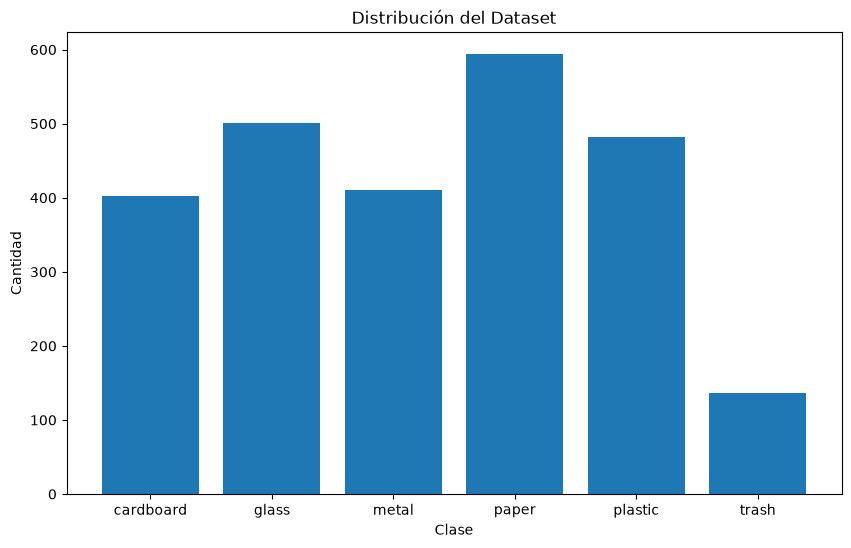

In [9]:

# GRAFICA DE BARRAS: DISTRIBUCION DEL DATASET

plt.figure(figsize=(10, 6))          # crea el lienzo de la grafica con tamano 10x6 pulgadas

plt.bar(nombre_clases, cantidad)            # dibuja barras: eje X = clases, altura = cantidad de imagenes

plt.title("Distribución del Dataset")  # titulo de la grafica

plt.xlabel("Clase")                  # etiqueta del eje X (horizontal): nombre de la clase

plt.ylabel("Cantidad")               # etiqueta del eje Y (vertical): numero de imagenes

plt.show()                           # muestra la grafica en pantalla

# FASE 3 - PREPARACIÓN DE LOS DATOS

In [10]:
# PARAMETROS DE LAS IMAGENES

tamano_imagen = (224, 224)

tamano_lote = 32   # define el numero de imagenes que se procesan juntas en cada paso
                             # (un "lote"; ayuda a entrenar mas rapido y de forma estable)

In [11]:

# CARGAR IMAGENES DE ENTRENAMIENTO (70%)

# Lee las imagenes desde las carpetas y las convierte en un dataset de TensorFlow.
# Keras asigna automaticamente la etiqueta segun el nombre de la carpeta.

datos_entrenamiento = tf.keras.utils.image_dataset_from_directory(  # funcion de Keras que carga imagenes desde carpetas

    ruta_datos,              # carpeta que contiene las subcarpetas por clase

    validation_split=0.30,   # 'validation_split' (parametro de Keras): reserva un 30% para validacion/prueba

    subset="training",       # 'subset' (parametro de Keras): pedimos el 70% de ENTRENAMIENTO

    seed=123,                # 'seed' = semilla fija: hace que el reparto sea siempre el mismo

    image_size=tamano_imagen,   # 'image_size': redimensiona cada imagen a 224x224

    batch_size=tamano_lote      # 'batch_size': agrupa las imagenes en lotes de 32

)

Found 2527 files belonging to 6 classes.
Using 1769 files for training.


In [12]:

# CARGAR EL 30% RESTANTE (se dividira luego en validacion + prueba)

# Usa la MISMA semilla (123) que el entrenamiento para no mezclar imagenes entre conjuntos.

datos_temporales = tf.keras.utils.image_dataset_from_directory(  # mismo cargador de Keras

    ruta_datos,              # misma carpeta de imagenes

    validation_split=0.30,   # mismo 30% reservado

    subset="validation",     # 'subset="validation"': ahora pedimos ese 30% restante

    seed=123,                # MISMA semilla -> el reparto es consistente con el de entrenamiento

    image_size=tamano_imagen,   # mismo tamano 224x224

    batch_size=tamano_lote      # mismos lotes de 32

)

Found 2527 files belonging to 6 classes.
Using 758 files for validation.


In [13]:
# ============================================================
# DIVIDIR EL 30% EN: PRUEBA (15%) + VALIDACION (15%)
# ============================================================
# datos_temporales (30%) se parte en dos mitades iguales:
#   - datos_prueba      -> para la evaluacion FINAL (datos que el modelo nunca vio)
#   - datos_validacion  -> para vigilar el entrenamiento epoca a epoca

lotes_validacion = tf.data.experimental.cardinality(datos_temporales)  # 'cardinality' = cuenta cuantos lotes hay

datos_prueba = datos_temporales.take(lotes_validacion // 2)   # 'take' = toma la PRIMERA mitad de los lotes -> prueba

datos_validacion = datos_temporales.skip(lotes_validacion // 2)  # 'skip' = salta esa mitad y toma el resto -> validacion
                                                                  # ('//' es division entera, sin decimales)

In [14]:
# ============================================================
# OPTIMIZACION DE DATOS

#Normalización
# EfficientNetB0 YA normaliza las imagenes por dentro y espera los pixeles
# en el rango [0, 255]. Si se divide entre 255  el rango se convierte en [0, 1] y  se rompe esa normalizacion interna

# 1) ordenamos  las clases en orden alfabetico ANTES de transformar los datos   este orden es el que usa el modelo internamente y el que se debem usar  en el reporte y en la matriz de confusion.
print("Orden REAL de las clases:", nombre_clases)

# 2) Optimizacion de rendimiento (se utiliza cache + prefetch = entrena mas rapido).
#    NO cambia los datos, solo acelera la lectura desde el disco.
autotune = tf.data.AUTOTUNE   # 'AUTOTUNE' = valor de TensorFlow que ajusta solo la velocidad de lectura

datos_entrenamiento = datos_entrenamiento.cache().prefetch(autotune)  # 'cache' guarda en memoria, 'prefetch' adelanta el siguiente lote
datos_validacion    = datos_validacion.cache().prefetch(autotune)
datos_prueba        = datos_prueba.cache().prefetch(autotune)

Orden REAL de las clases: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


# FASE 4 - MODELADO

In [15]:
# ============================================================
# CARGAR EL MODELO BASE: EfficientNetB0 (TRANSFER LEARNING)
# ============================================================
# En vez de entrenar una red desde cero (necesitaria millones de imagenes),
# reutilizamos EfficientNetB0 que YA aprendio a "ver" con ImageNet.
from tensorflow.keras.applications import EfficientNetB0   # importamos el modelo EfficientNetB0 de Keras

modelo_base = EfficientNetB0(        # creamos el modelo base

    weights='imagenet',          # 'weights="imagenet"': trae los pesos ya entrenados con millones de imagenes

    include_top=False,           # 'include_top=False': quitamos la ultima capa original (la de las 1000 clases de ImageNet)
                                 # para poner la nuestra (6 clases de residuos)

    input_shape=(224, 224, 3)    # 'input_shape': tamano de entrada = 224x224 pixeles, 3 canales de color (RGB)

)

modelo_base.trainable = False    # '.trainable = False': CONGELAMOS el modelo base.
                                 # No se reentrena; solo aprovechamos lo que ya sabe (mas rapido y necesita menos datos)

In [16]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# CONSTRUIR EL MODELO


aumento_datos = tf.keras.Sequential([                                # 'Sequential' = apila capas una tras otra
    tf.keras.layers.RandomFlip("horizontal"),                        # voltea la imagen al azar
    tf.keras.layers.RandomRotation(0.15),                            # la rota un poco (15%) al azar
    tf.keras.layers.RandomZoom(0.15),                                # le hace zoom (15%) al azar
    tf.keras.layers.RandomTranslation(0.1, 0.1),                     # la mueve (el objeto no siempre va centrado)
    tf.keras.layers.RandomContrast(0.2),                             # varia el contraste (ayuda con reflejos)
    tf.keras.layers.RandomBrightness(0.2, value_range=(0, 255)),     # varia el brillo (luz de la camara)
], name="aumento_de_datos")                                          # 'name': nombre interno de este bloque

modelo = tf.keras.Sequential([                   # creamos el modelo final apilando capas en orden

    tf.keras.layers.Input(shape=(224, 224, 3)),  # 'Input': capa de entrada, recibe imagenes 224x224 RGB
    
     #  aplica las variaciones (solo durante el entrenamiento)
    aumento_datos,      
   
    #Normalizo los datos para las imagenes
    tf.keras.layers.Lambda(preprocess_input),

    modelo_base,                                 #  EfficientNetB0 congelado (extrae las caracteristicas)

    tf.keras.layers.GlobalAveragePooling2D(),    # 'GlobalAveragePooling2D': resume toda la info en un vector de numeros

    tf.keras.layers.Dense(256, activation='relu'),  # 'Dense(128)': capa de 128 neuronas que combina caracteristicas
                                                     # 'relu' = funcion de activacion (deja pasar lo positivo)

    tf.keras.layers.Dropout(0.4),                # 'Dropout(0.3)': apaga el 30% de las neuronas al azar -> evita sobreajuste

    tf.keras.layers.Dense(len(nombre_clases), activation='softmax')  # capa FINAL: una neurona por clase (len = cantidad de clases = 6)
                                                 # 'softmax' = convierte las salidas en probabilidades (suman 100%)

])

modelo.summary()   # '.summary()': imprime un resumen de las capas y cuantos parametros se entrenan

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aumento_de_datos (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [17]:
# ============================================================
# COMPILAR EL MODELO (configurar como va a aprender)
# ============================================================
modelo.compile(   # '.compile()': prepara el modelo para entrenar (define como aprende y como se mide)

    optimizer='adam',                          # 'optimizer="adam"': algoritmo que ajusta los pesos (Adam es eficiente y popular)

    loss='sparse_categorical_crossentropy',    # 'loss': funcion de error para clasificacion de varias clases.
                                               # "sparse" porque las etiquetas son numeros (0,1,2...) y no listas one-hot

    metrics=['accuracy']                       # 'metrics=["accuracy"]': la metrica a vigilar = exactitud (% de aciertos)

)

In [18]:

# ENTRENAR EL MODELO

# Una EPOCA = una pasada completa por todas las imagenes de entrenamiento.


conteo = {c: len(os.listdir(os.path.join(ruta_datos, c))) for c in nombre_clases}  # cuenta imagenes por clase (diccionario clase->cantidad)
suma_imagenes = sum(conteo.values())                                                # suma total de imagenes
peso_clases = {i: suma_imagenes / (len(nombre_clases) * conteo[c])                 # formula del peso para cada clase
               for i, c in enumerate(nombre_clases)}                               # 'enumerate' da el indice (0,1,2..) y el nombre
print("Peso de cada clase:", peso_clases)
#  CALLBACKS: ayudas automaticas que actuan durante el entrenamiento.
controles = [                                  # 'controles' = nuestra lista de ayudas 3

    tf.keras.callbacks.EarlyStopping(          # 'EarlyStopping': detiene el entrenamiento si ya no mejora
        monitor='val_accuracy',                # 'monitor': vigila la exactitud en validacion
        patience=5,                            # 'patience=5': espera 5 epocas sin mejora antes de parar
        restore_best_weights=True,             # 'restore_best_weights': se queda con los mejores pesos encontrados
        verbose=1),                            # 'verbose=1': avisa por pantalla cuando actua

    tf.keras.callbacks.ReduceLROnPlateau(      # 'ReduceLROnPlateau': baja la tasa de aprendizaje si se estanca
        monitor='val_loss',                    # vigila el error en validacion
        factor=0.5,                            # 'factor=0.5': cuando se estanca, reduce la tasa a la mitad
        patience=3,                            # espera 3 epocas sin mejora antes de reducirla
        verbose=1),                            # avisa por pantalla cuando actua
]

# 3) ENTRENAR
historial = modelo.fit(            # '.fit()': inicia el entrenamiento; 'historial' guarda los resultados de cada epoca
    datos_entrenamiento,           # datos con los que el modelo APRENDE
    validation_data=datos_validacion,  # 'validation_data': datos con los que se autoevalua en cada epoca
    epochs=25,                     # 'epochs=25': maximo 25 pasadas (EarlyStopping puede cortar antes si ya no mejora)
    class_weight=peso_clases,      # 'class_weight': aplica los pesos para compensar el desbalance
    callbacks=controles            # 'callbacks': nuestra lista de ayudas (EarlyStopping + ReduceLROnPlateau)
)
# 'historial' guarda el accuracy y loss de cada epoca para graficarlos despues.

Peso de cada clase: {0: 1.0450785773366418, 1: 0.8406520292747838, 2: 1.0272357723577237, 3: 0.7090347923681257, 4: 0.873789764868603, 5: 3.0742092457420926}
Epoch 1/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.6721 - loss: 0.8872 - val_accuracy: 0.8262 - val_loss: 0.4839 - learning_rate: 0.0010
Epoch 2/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8202 - loss: 0.4877 - val_accuracy: 0.8449 - val_loss: 0.4264 - learning_rate: 0.0010
Epoch 3/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8621 - loss: 0.3893 - val_accuracy: 0.8422 - val_loss: 0.4023 - learning_rate: 0.0010
Epoch 4/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8813 - loss: 0.3191 - val_accuracy: 0.8636 - val_loss: 0.3640 - learning_rate: 0.0010
Epoch 5/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8932 - loss: 0.2962 - val_accuracy: 0.8690 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 6/25
56/56 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.9050 - loss: 0.2428 - val

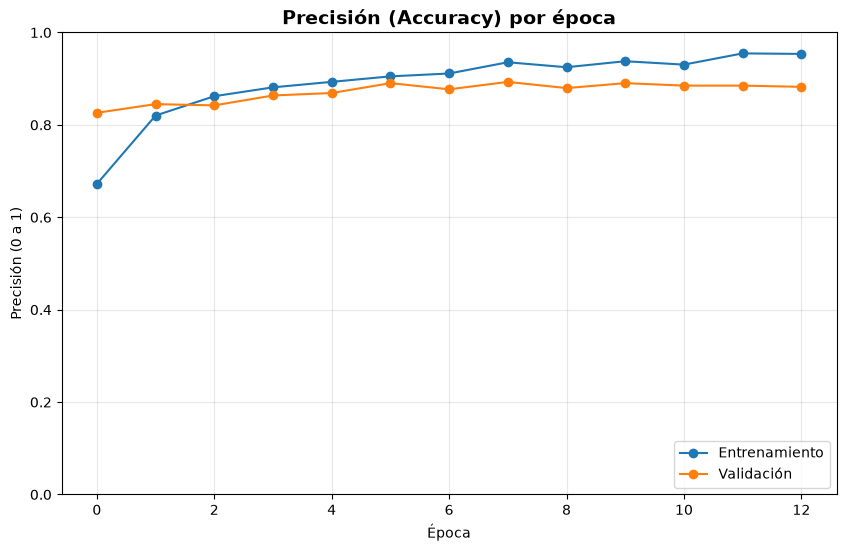

In [19]:

# GRAFICA DE PRECISION (ACCURACY)

# Compara como mejora el % de aciertos en ENTRENAMIENTO vs VALIDACION.
# - Si ambas suben juntas -> el modelo esta aprendiendo bien.
# - Si entrenamiento sube mucho y validacion se queda abajo -> sobreajuste.

plt.figure(figsize=(10, 6))   # crea el lienzo de la grafica (tamano 10x6)

plt.plot(historial.history['accuracy'],     marker='o', label='Entrenamiento')  # linea de exactitud en entrenamiento (con puntos 'o')
plt.plot(historial.history['val_accuracy'], marker='o', label='Validación')     # linea de exactitud en validacion
# 'historial.history' = diccionario con los numeros guardados de cada epoca

plt.title('Precisión (Accuracy) por época', fontsize=14, fontweight='bold')  # titulo de la grafica
plt.xlabel('Época')                  # eje X: numero de epoca
plt.ylabel('Precisión (0 a 1)')      # eje Y: exactitud (0 = 0%, 1 = 100%)
plt.ylim(0, 1)                       # 'ylim': fija el eje Y de 0 a 1 para leerlo facil
plt.legend(loc='lower right')        # 'legend': muestra el cuadrito que dice que linea es cual
plt.grid(True, alpha=0.3)            # 'grid': dibuja una cuadricula suave de fondo (alpha = transparencia)
plt.show()                           # muestra la grafica

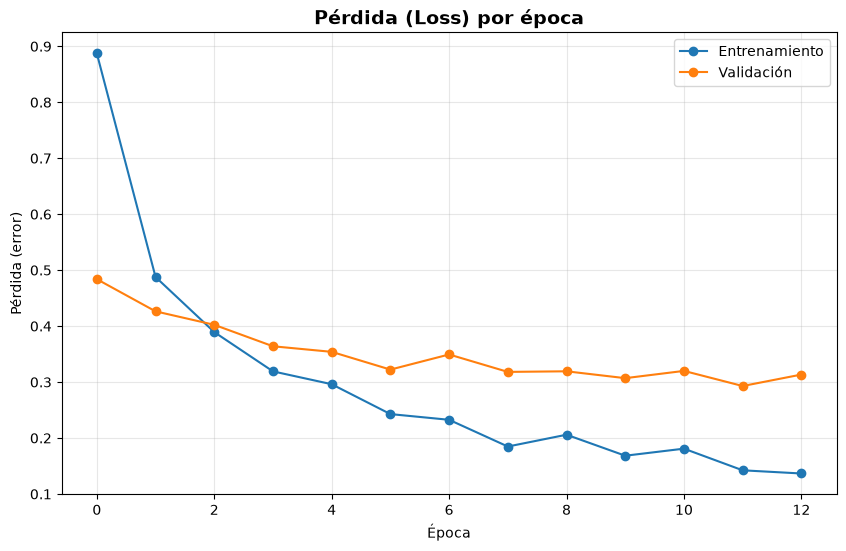

In [20]:

# GRAFICA DE PERDIDA (LOSS)

# El "loss" (error) mide que tan equivocado esta el modelo. DEBE BAJAR con las epocas.
# - Si el loss de validacion empieza a SUBIR mientras el de entrenamiento baja
#   -> el modelo se esta sobreajustando (memoriza en vez de aprender).

plt.figure(figsize=(10, 6))   # crea el lienzo de la grafica

plt.plot(historial.history['loss'],     marker='o', label='Entrenamiento')  # linea de error en entrenamiento
plt.plot(historial.history['val_loss'], marker='o', label='Validación')     # linea de error en validacion

plt.title('Pérdida (Loss) por época', fontsize=14, fontweight='bold')  # titulo
plt.xlabel('Época')                  # eje X: numero de epoca
plt.ylabel('Pérdida (error)')        # eje Y: valor del error (mas bajo = mejor)
plt.legend(loc='upper right')        # cuadrito de leyenda
plt.grid(True, alpha=0.3)            # cuadricula suave de fondo
plt.show()                           # muestra la grafica

In [21]:

# AJUSTE FINO


# (1e-5 = 0.00001). Esto ajusta finamente la red al dataset de residuos y suele
# subir la precision varios puntos.

modelo_base.trainable = True   # '.trainable = True': DESCONGELAMOS el modelo base (ahora si se reentrena)


for capa in modelo_base.layers:                              # recorremos cada capa del modelo base
    if isinstance(capa, tf.keras.layers.BatchNormalization): # 'isinstance' = pregunta si la capa es de tipo BatchNormalization
        capa.trainable = False                               # si lo es, la dejamos congelada

# Recompilar SIEMPRE despues de cambiar 'trainable', con tasa MUY baja
# para no destruir lo que el modelo ya aprendio.
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 'Adam' con 'learning_rate=1e-5' (tasa de aprendizaje muy baja)
    loss='sparse_categorical_crossentropy',                  # misma funcion de error que antes
    metrics=['accuracy']                                     # misma metrica: exactitud
)

historial_ajuste = modelo.fit(         # entrenamos otra vez; guardamos el resultado en 'historial_ajuste'
    datos_entrenamiento,               # mismos datos de entrenamiento
    validation_data=datos_validacion,  # mismos datos de validacion
    epochs=10,                         # solo 10 epocas extra (es un ajuste fino)
    class_weight=peso_clases,          # seguimos compensando el desbalance
    callbacks=controles                # reutilizamos las mismas ayudas (EarlyStopping + ReduceLROnPlateau)
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 296s 4s/step - accuracy: 0.9401 - loss: 0.1617 - val_accuracy: 0.8743 - val_loss: 0.3189 - learning_rate: 1.0000e-05
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - accuracy: 0.9469 - loss: 0.1511 - val_accuracy: 0.8957 - val_loss: 0.3027 - learning_rate: 1.0000e-05
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9616 - loss: 0.1265
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
56/56 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - accuracy: 0.9570 - loss: 0.1281 - val_accuracy: 0.9064 - val_loss: 0.2936 - learning_rate: 1.0000e-05
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.9542 - loss: 0.1292 - val_accuracy: 0.8957 - val_loss: 0.2901 - learning_rate: 5.0000e-06
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.9525 - loss: 0.1313 - val_accuracy: 0.8984 - val_loss: 0.2873 - learning_rate: 5.0000e-06
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.9604 - loss:

# FASE 5 - EVALUACIÓN

In [26]:
#Verificacion de predicciones 
print("="*60)
print("VERIFICACIÓN DE PREDICCIONES")
print("="*60)
for imagenes, etiquetas in datos_prueba.take(1):
    predicciones = modelo.predict(imagenes)
    confianza = np.max(predicciones, axis=1)
    clases_predichas = np.argmax(predicciones, axis=1)
    for i in range(min(10, len(etiquetas))):
        
        clase_real = nombre_clases[int(etiquetas[i])]
        clase_predicha = nombre_clases[clases_predichas[i]]
        
        print(f"Clase Real     : {clase_real}")
        print(f"Clase Predicha : {clase_predicha}")
        print(f"Confianza      : {confianza[i]*100:.2f}%")
        
        print("-"*50)
      

VERIFICACIÓN DE PREDICCIONES
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 675ms/step
Clase Real     : plastic
Clase Predicha : plastic
Confianza      : 51.64%
--------------------------------------------------
Clase Real     : cardboard
Clase Predicha : cardboard
Confianza      : 86.77%
--------------------------------------------------
Clase Real     : glass
Clase Predicha : glass
Confianza      : 86.93%
--------------------------------------------------
Clase Real     : cardboard
Clase Predicha : cardboard
Confianza      : 100.00%
--------------------------------------------------
Clase Real     : plastic
Clase Predicha : plastic
Confianza      : 99.78%
--------------------------------------------------
Clase Real     : glass
Clase Predicha : glass
Confianza      : 71.29%
--------------------------------------------------
Clase Real     : cardboard
Clase Predicha : cardboard
Confianza      : 100.00%
--------------------------------------------------
Clase Real     : plastic
Clase Predicha : trash
Con

In [27]:

# HERRAMIENTAS DE EVALUACION (scikit-learn)

from sklearn.metrics import classification_report   # reporte: precision, recall, f1 por clase

from sklearn.metrics import confusion_matrix         # tabla de aciertos vs confusiones

In [28]:
# ============================================================
# EVALUACION FINAL CON DATOS DE PRUEBA (datos_prueba)
# ============================================================
# Mide el rendimiento REAL con imagenes que el modelo NUNCA vio al entrenar.
# Este es el numero clave para defender el proyecto.

perdida_prueba, exactitud_prueba = modelo.evaluate(datos_prueba)  # '.evaluate()' devuelve el error y la exactitud en prueba

print(f"\nPrecisión final en prueba: {exactitud_prueba*100:.2f}%")  # mostramos la exactitud en porcentaje (x100, 2 decimales)
print(f"Pérdida final en prueba:   {perdida_prueba:.4f}")           # mostramos el error con 4 decimales

12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 646ms/step - accuracy: 0.9115 - loss: 0.3009

Precisión final en prueba: 91.15%
Pérdida final en prueba:   0.3009


In [29]:
# ============================================================
# OBTENER PREDICCIONES PARA EL REPORTE Y LA MATRIZ
# ============================================================
# Recorre el conjunto de prueba y guarda:
#   - etiquetas_reales:   la clase REAL de cada imagen
#   - etiquetas_predichas: la clase que PREDIJO el modelo

etiquetas_reales = []      # lista vacia para las clases verdaderas
etiquetas_predichas = []   # lista vacia para las clases que adivina el modelo

for imagenes, etiquetas in datos_prueba:           # recorremos los lotes de prueba (imagenes + sus etiquetas reales)

    prediccion = modelo.predict(imagenes)          # '.predict()' = el modelo da las probabilidades de cada clase

    etiquetas_reales.extend(etiquetas.numpy())     # 'extend' agrega las etiquetas reales (.numpy() las pasa a numeros normales)

    etiquetas_predichas.extend(np.argmax(prediccion, axis=1))  # 'np.argmax' = elige la clase con la probabilidad mas alta

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 728ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step


In [30]:
# ============================================================
# REPORTE DE CLASIFICACION
# ============================================================
# Por cada clase muestra:
#   - precision: de lo que predijo como X, cuanto era realmente X
#   - recall:    de todo lo que era X, cuanto detecto
#   - f1-score:  equilibrio entre precision y recall (1.0 = perfecto)
print(classification_report(   # 'classification_report' (de scikit-learn) arma la tabla de metricas
    etiquetas_reales,          # clases verdaderas
    etiquetas_predichas,       # clases que predijo el modelo
    target_names=nombre_clases,  # 'target_names': muestra el NOMBRE de cada clase en vez de 0,1,2...
    zero_division=0            # 'zero_division=0': evita avisos si alguna clase no se predice nunca
))

              precision    recall  f1-score   support

   cardboard       0.91      0.95      0.93        64
       glass       0.91      0.92      0.92        77
       metal       0.90      0.97      0.93        59
       paper       0.95      0.92      0.93       100
     plastic       0.91      0.85      0.88        59
       trash       0.79      0.76      0.78        25

    accuracy                           0.91       384
   macro avg       0.90      0.89      0.89       384
weighted avg       0.91      0.91      0.91       384



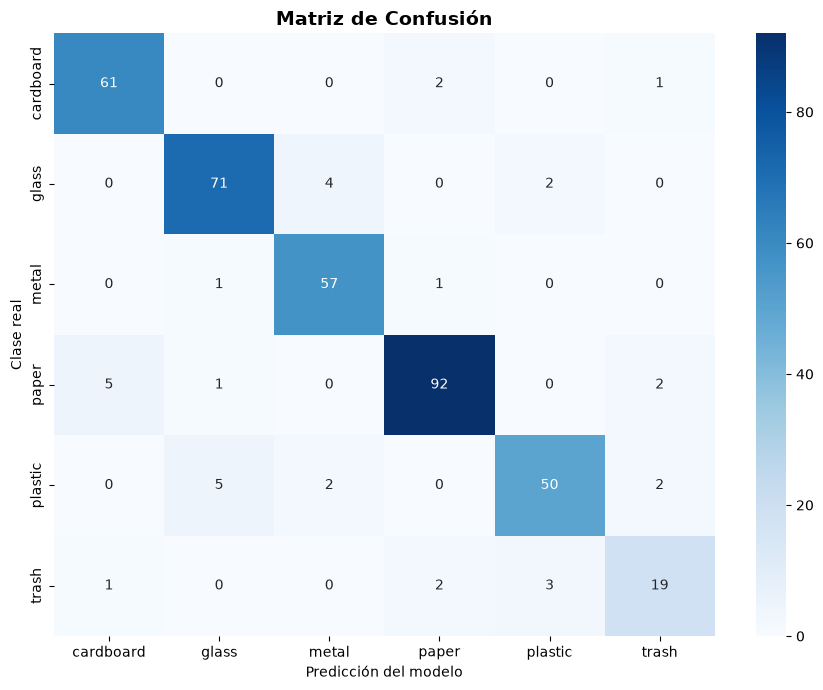

In [31]:
# ============================================================
# MATRIZ DE CONFUSION
# ============================================================
# Tabla: filas = clase REAL, columnas = clase PREDICHA.
# La DIAGONAL (esquina sup-izq a inf-der) son los ACIERTOS.
# Todo lo de fuera de la diagonal son CONFUSIONES (errores).
# Ej: cuantas veces una "glass" real la predijo como "plastic".

matriz = confusion_matrix(etiquetas_reales, etiquetas_predichas)  # 'confusion_matrix' arma la tabla de aciertos/errores

plt.figure(figsize=(9, 7))   # lienzo de la grafica
sns.heatmap(                 # 'heatmap' (de seaborn) dibuja la tabla con colores
    matriz,                  # la matriz de numeros a dibujar
    annot=True,              # 'annot=True': escribe el numero dentro de cada celda
    fmt='d',                 # 'fmt="d"': formato de numero entero (sin decimales)
    cmap='Blues',            # 'cmap="Blues"': escala de color azul (mas oscuro = mas casos)
    xticklabels=nombre_clases,  # nombres de clase en el eje X (orden REAL del modelo)
    yticklabels=nombre_clases   # nombres de clase en el eje Y
)
plt.title('Matriz de Confusión', fontsize=14, fontweight='bold')  # titulo
plt.xlabel('Predicción del modelo')  # eje X: lo que el modelo predijo
plt.ylabel('Clase real')             # eje Y: lo que realmente era
plt.tight_layout()                   # 'tight_layout': acomoda todo para que no se corten los textos
plt.show()                           # muestra la grafica

# FASE 6 - DESPLIEGUE

In [32]:
# ============================================================
# GUARDAR EL MODELO ENTRENADO
# Guarda toda la red (arquitectura + pesos aprendidos) en un solo archivo.
# Asi se puede reutilizar despues SIN volver a entrenar (ej. en la API con FastAPI).
modelo.save("modelo_residuos.keras")   # '.save()': guarda el modelo en el archivo modelo_residuos.keras

In [ ]:
# ============================================================
# DESCARGAR EL MODELO A TU COMPUTADORA
# ============================================================
# Baja el archivo .keras desde Colab a tu PC para usarlo en el proyecto local
# (la API de FastAPI/Flask lo cargara para hacer las predicciones).
from google.colab import files

files.download("modelo_residuos.keras")

### Clasificación de imágenes desde la cámara

Ahora, vamos a añadir la funcionalidad para clasificar imágenes capturadas directamente desde tu cámara web usando el modelo entrenado. Necesitaremos cargar el modelo guardado, capturar una imagen, preprocesarla para que coincida con la entrada del modelo y luego realizar la predicción.

In [39]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predecir_seguro(ruta_imagen):

    img = image.load_img(
        ruta_imagen,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    predicciones = modelo.predict(
        img_array,
        verbose=0
    )

    indice = np.argmax(predicciones)

    confianza = float(
        np.max(predicciones)
    )

    if confianza < 0.75:

        return {
            "clase":"desconocido",
            "confianza":confianza
        }

    return {
        "clase":nombre_clases[indice],
        "confianza":confianza
    }

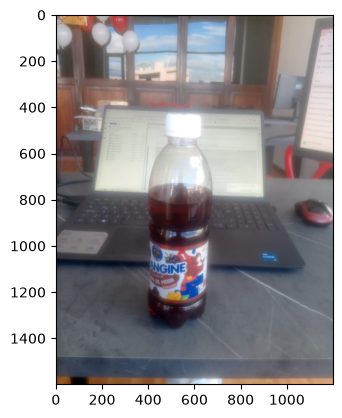

(1600, 1200, 3)


In [72]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("imagenes_reales/botella1.jpeg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()

print(img.shape)

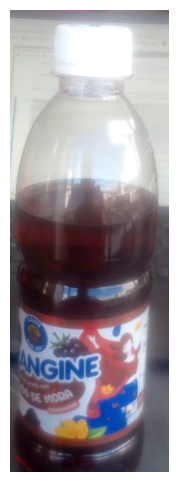

In [79]:
crop = img[400:1300, 390:700]
crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(crop_rgb)
plt.axis("off")
plt.show()

In [80]:
cv2.imwrite(
    "imagenes_reales/botella_crop.jpg",
    crop
)

True

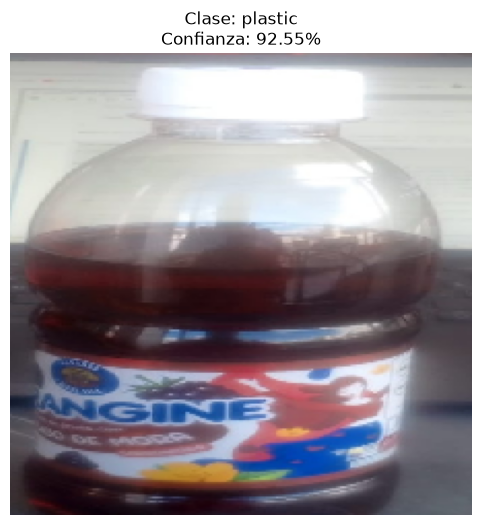

Clase detectada: plastic
Confianza: 92.55%


('plastic', np.float32(0.92549396))

In [85]:
predecir_imagen(
    "imagenes_reales/botella_crop.jpg"
)